In [1]:
import os
import numpy as np

In [2]:
from tqdm.notebook import tqdm, trange

In [3]:
import torch
from sedflow import util as U
from sedflow import data as D

In [4]:
import corner as DFM
# --- plotting ---
import matplotlib as mpl
import matplotlib.pyplot as plt
#mpl.rcParams['text.usetex'] = True
#mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

In [5]:
if torch.cuda.is_available(): device = 'cuda'
else: device = 'cpu'

In [6]:
#bands = 'ugrizJ'
bands = 'grzW1W2'

In [7]:
qphis = U.read_best_qphi('qphi.modela.%s.theta.nmgysigz' % bands, device=device)

29 models trained
[2, 10, 23, 13, 9]


In [8]:
x_test, y_test = D.load_modela('test', bands=bands, infer_redshift=False)

In [9]:
theta_lbls = [r'$\log M_*$', r"$\beta'_1$", r"$\beta'_2$", r"$\beta'_3$", r'$f_{\rm burst}$', r'$t_{\rm burst}$', r'$\log \gamma_1$', r'$\log \gamma_2$', r'$\tau_1$', r'$\tau_2$', r'$n_{\rm dust}$']

  0%|          | 0/5 [00:00<?, ?it/s]

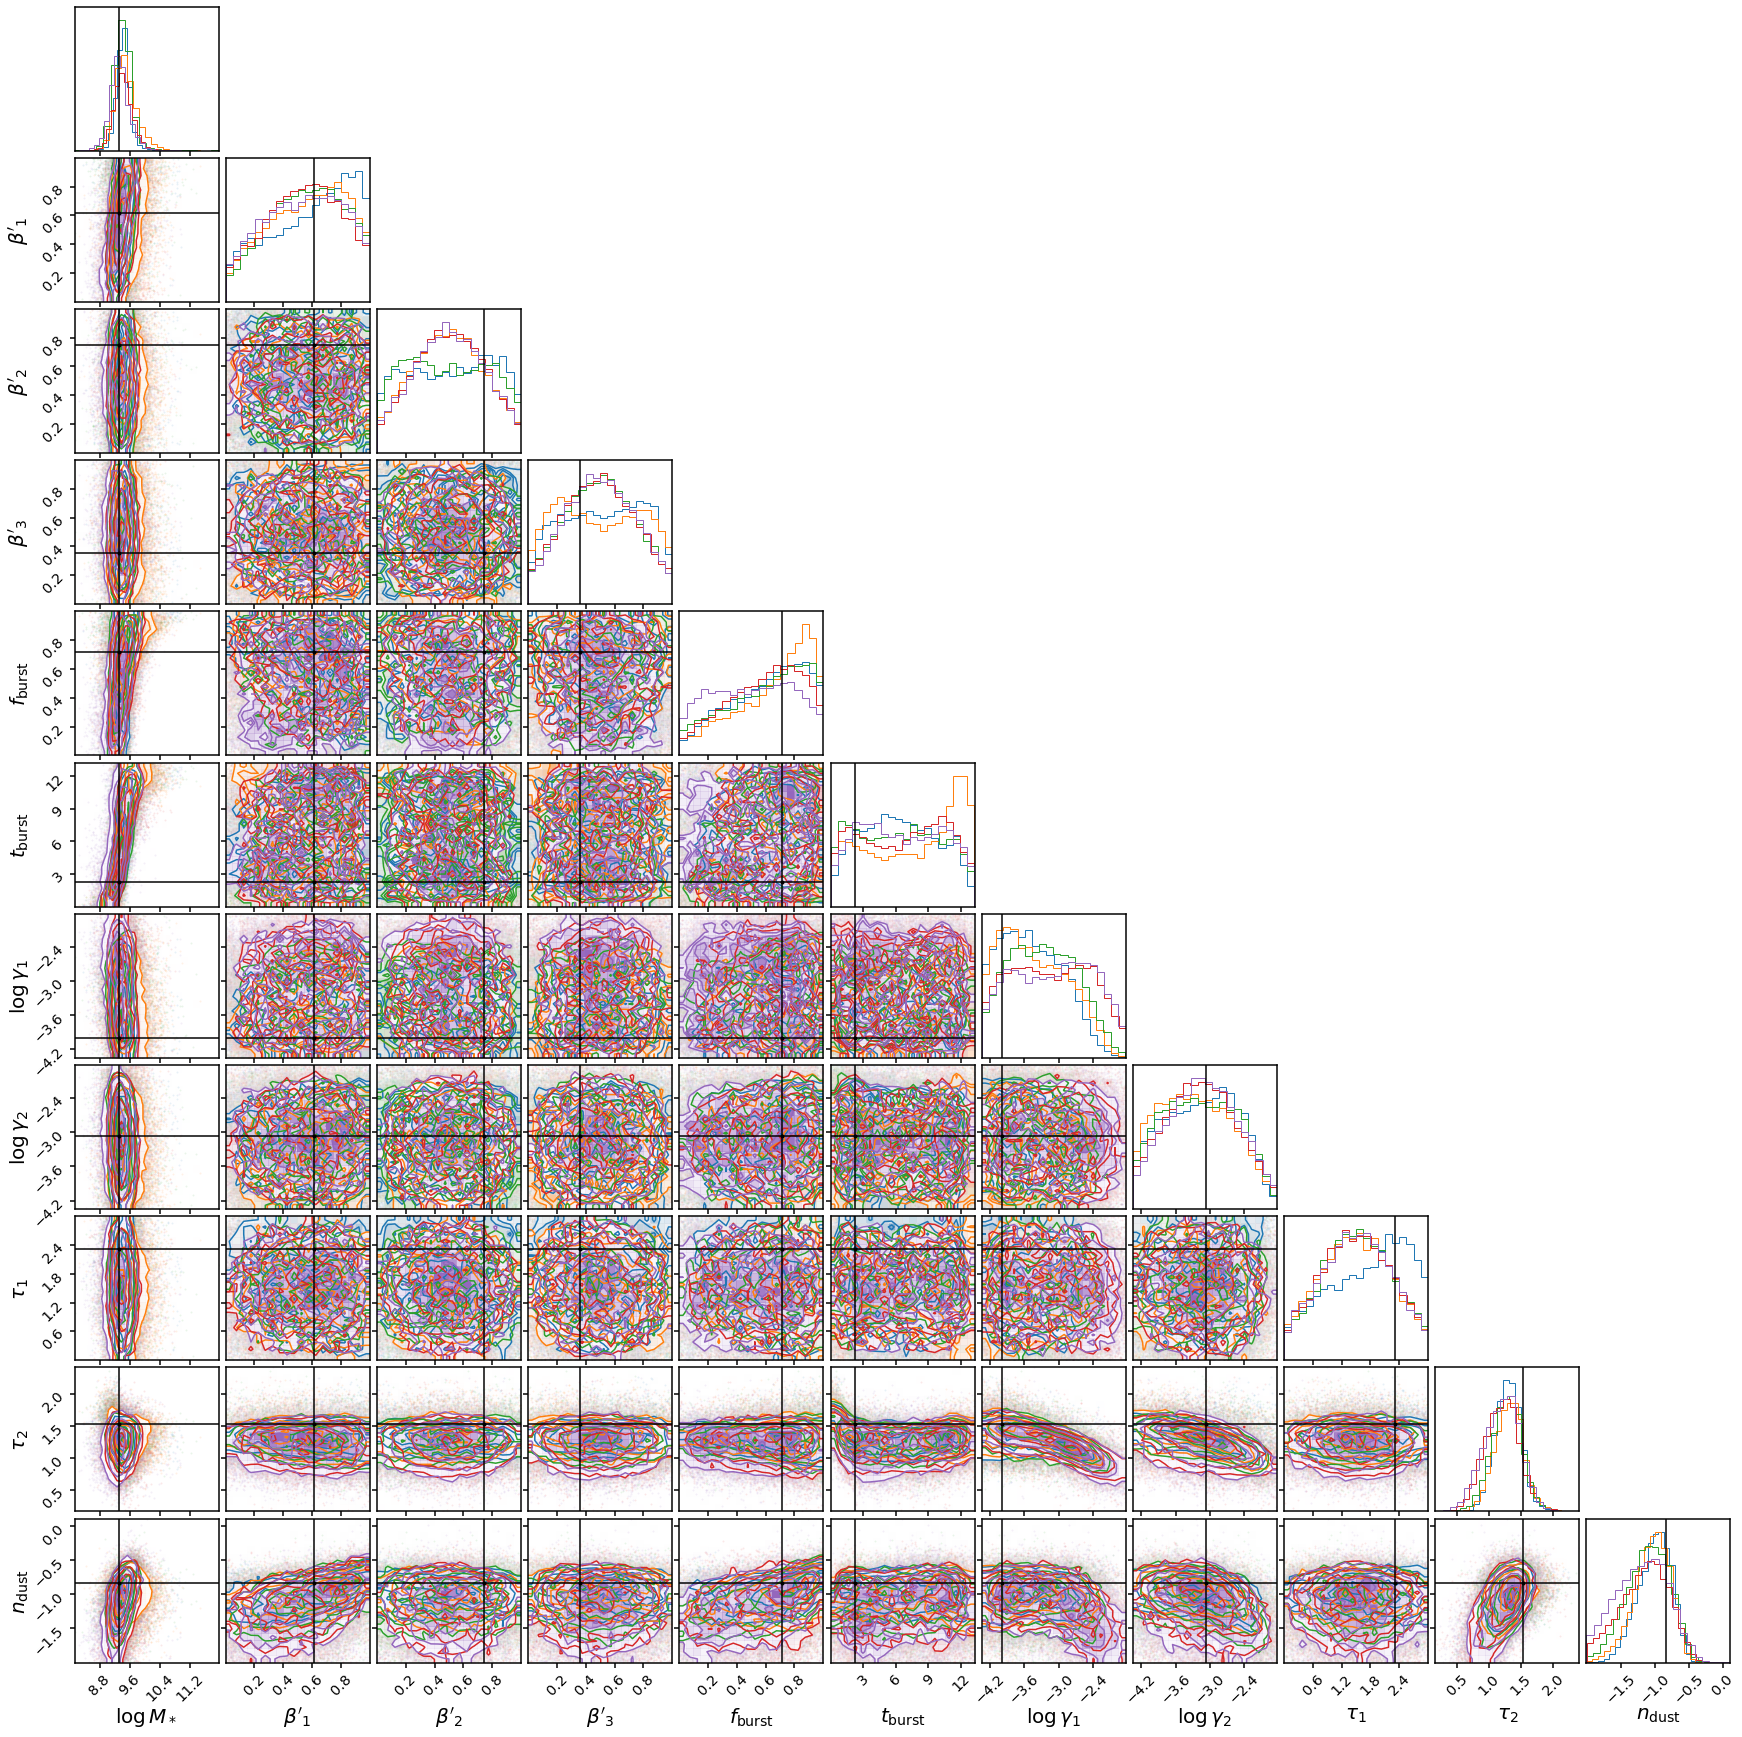

In [10]:
igal = np.random.choice(np.arange(x_test.shape[0]))


fig = None 
for i in trange(len(qphis)):
    qphi = qphis[i]
    _samp = qphi.sample((10000,),
                       x=torch.tensor(y_test[igal], dtype=torch.float32).to(device), 
                       show_progress_bars=False)
    fig = DFM.corner(_samp.detach().cpu().numpy(), color='C%i' % i, 
                     labels=theta_lbls, label_kwargs={'fontsize':20}, fig=fig)
DFM.overplot_lines(fig, x_test[igal], color='k')
DFM.overplot_points(fig, [x_test[igal]], color='k')

# SBC

In [11]:
n_sample = 10000

ranks, x_nde = [], []
for i in trange(500):#y_test.shape[0]): 
    x_samp = []
    for qphi in qphis: 
        _samp = qphi.sample((int(n_sample/len(qphis)),),
                           x=torch.tensor(y_test[i], dtype=torch.float32).to(device), 
                           show_progress_bars=False)

        x_samp.append(_samp.detach().cpu().numpy())
    x_nde.append(np.concatenate(np.array(x_samp), axis=0))        

    _ranks = []
    for i_dim in range(x_nde[-1].shape[1]): 
        _ranks.append(np.mean(x_nde[-1][:,i_dim].flatten() < x_test[i, i_dim]))
    ranks.append(_ranks)

ranks = np.array(ranks)
x_nde = np.array(x_nde)

  0%|          | 0/500 [00:00<?, ?it/s]

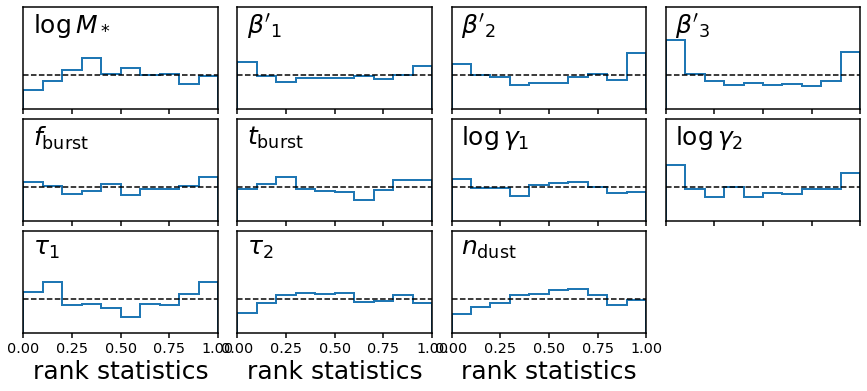

In [12]:
fig = plt.figure(figsize=(15, 6))
for i in range(x_test.shape[1]): 
    sub = fig.add_subplot(3,4,i+1)
    _ = sub.hist(ranks[:,i], range=(0., 1), bins=10, histtype='step', density=True, linewidth=2, color='C0') 
    sub.plot([0., 1.], [1., 1.], c='k', ls='--')
    
    sub.text(0.05, 0.95, theta_lbls[i], fontsize=25, transform=sub.transAxes, ha='left', va='top')
    
    if i > 7: sub.set_xlabel('rank statistics', fontsize=25)
    if i < 8: sub.set_xticklabels([])
    sub.set_xlim(0., 1.)
    sub.set_ylim(0., 3.)
    sub.set_yticks([])
fig.subplots_adjust(hspace=0.1, wspace=0.1)